In this notebook, we consider the results for the squared exponential correlation function.

In [15]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch
import scipy
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

In [16]:
# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
sigma = 1.0 # Standard deviation (amplitude) of the process

In [17]:
num_points_taus = 50
taus = torch.linspace(0.01, 1.0, num_points_taus)

num_points_zeta = 50
zeta = torch.linspace(0.0, 3.0, num_points_zeta) 

mean_rates = torch.zeros(num_points_taus, num_points_zeta)
fano_factors = torch.zeros(num_points_taus, num_points_zeta)

In [18]:
for i in range(num_points_taus):
    for j in range(num_points_zeta):
        u = zeta[j] * sigma
        tau = taus[i]
        model = formula.GaussianUpCrossingsDimless(r_func=process.r_squared_exp, u=u, tau=tau, sigma=sigma)
        mean_rates[i, j] = model.upcrossing_mean_rate()
        fano_factors[i, j] = model.upcrossing_fano_factor_CLT(epsilon_left=1e-2, epsilon_right=1e-5)

/var/folders/n7/dvsmt08j14310vr4k9jmj3s80000gn/T/ipykernel_5762/4256053768.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  edges[1:-1] = (arr[:-1] + arr[1:]) / 2.0


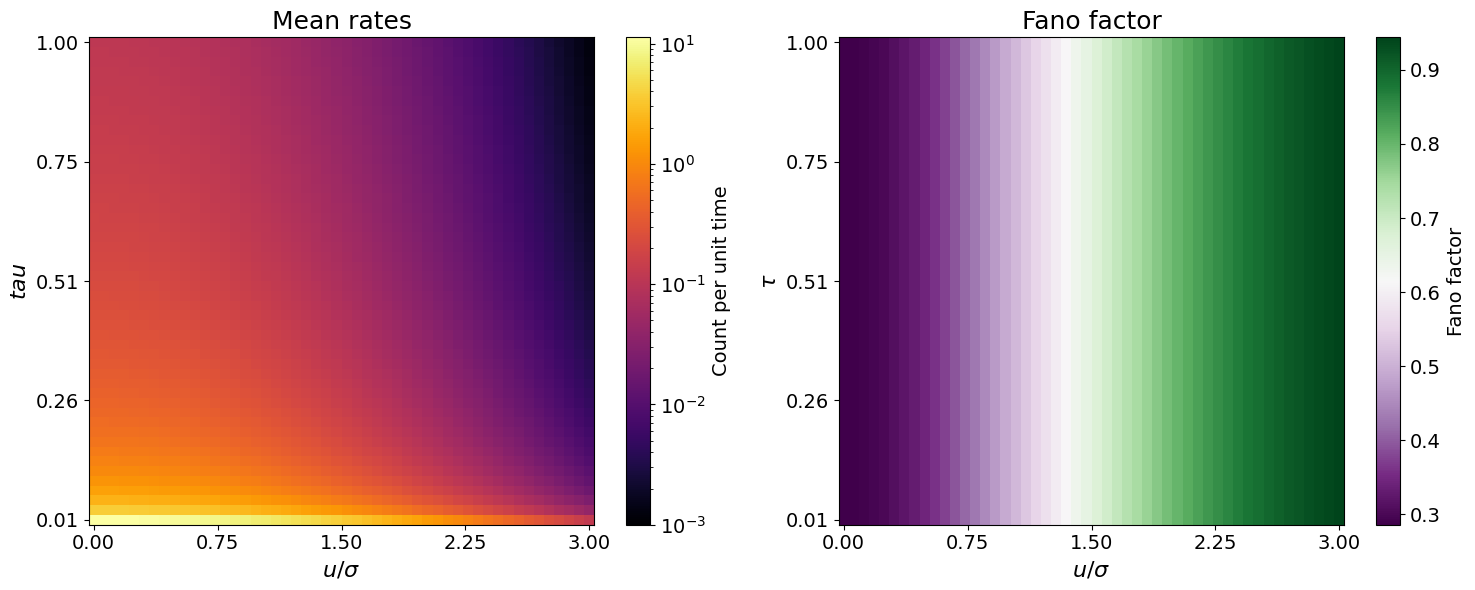

In [19]:
# If necessary, ensure that taus is increasing:
if taus[0] > taus[-1]:
    taus = np.flipud(taus)
    mean_rates = np.flipud(mean_rates)
    fano_factors = np.flipud(fano_factors)

# -----------------------
# Helper: Compute cell edges for arbitrary spacing
# -----------------------
def compute_edges(arr):
    """
    Given a 1D array of cell centers, compute cell edges.
    """
    edges = np.empty(len(arr) + 1)
    # Interior edges: midpoints
    edges[1:-1] = (arr[:-1] + arr[1:]) / 2.0
    # Extrapolate first and last edge
    edges[0] = arr[0] - (arr[1] - arr[0]) / 2.0
    edges[-1] = arr[-1] + (arr[-1] - arr[-2]) / 2.0
    return edges

# Compute cell edges from the center values
zeta_edges = compute_edges(zeta)
taus_edges = compute_edges(taus)

# -----------------------
# Plotting parameters
# -----------------------
cmap_mean = 'inferno'
cmap_fano = 'PRGn'
label_fontsize = 16
tick_fontsize = 14
title_fontsize = 18
cbar_labelsize = 14

# Number of ticks to display on each axis (independent of underlying spacing)
num_ticks = 5
x_ticks = np.linspace(zeta.min(), zeta.max(), num_ticks)
y_ticks = np.linspace(taus.min(), taus.max(), num_ticks)

# -----------------------
# Create the figure and subplots

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Left subplot: Mean Rates with Linear Scale ----
# Set a small threshold epsilon for the lower bound (adjust as needed)
epsilon = 1e-3
# Clip the data so that no value is below epsilon
adjusted_mean_rates = np.clip(mean_rates, epsilon, None)
# Set up LogNorm with vmin set to epsilon and vmax as the maximum of the adjusted data
log_norm = LogNorm(vmin=epsilon, vmax=adjusted_mean_rates.max())

pc0 = axes[0].pcolormesh(zeta_edges, taus_edges, adjusted_mean_rates, shading='auto',
                         cmap=cmap_mean, norm=log_norm)
cbar0 = fig.colorbar(pc0, ax=axes[0])
cbar0.set_label("Count per unit time", fontsize=cbar_labelsize)
cbar0.ax.tick_params(labelsize=tick_fontsize)

axes[0].set_xlabel(r'$u/\sigma$', fontsize=label_fontsize)
axes[0].set_ylabel(r'$tau$', fontsize=label_fontsize)
axes[0].set_title('Mean rates', fontsize=title_fontsize)
axes[0].set_xticks(x_ticks)
axes[0].set_yticks(y_ticks)
axes[0].set_xticklabels([f"{val:.2f}" for val in x_ticks], fontsize=tick_fontsize)
axes[0].set_yticklabels([f"{val:.2f}" for val in y_ticks], fontsize=tick_fontsize)

# -----------------------
# Right subplot: Fano Factors
# -----------------------
# Plot Fano factors on a linear scale
pc1 = axes[1].pcolormesh(zeta_edges, taus_edges, fano_factors, shading='auto',
                         cmap=cmap_fano)
cbar1 = fig.colorbar(pc1, ax=axes[1])
cbar1.set_label("Fano factor", fontsize=cbar_labelsize)
cbar1.ax.tick_params(labelsize=tick_fontsize)

axes[1].set_xlabel(r'$u/\sigma$', fontsize=label_fontsize)
axes[1].set_ylabel(r'$\tau$', fontsize=label_fontsize)
axes[1].set_title('Fano factor', fontsize=title_fontsize)
axes[1].set_xticks(x_ticks)
axes[1].set_yticks(y_ticks)
axes[1].set_xticklabels([f"{val:.2f}" for val in x_ticks], fontsize=tick_fontsize)
axes[1].set_yticklabels([f"{val:.2f}" for val in y_ticks], fontsize=tick_fontsize)


plt.tight_layout()
plt.show()

In [20]:
model = formula.GaussianUpCrossings(r_func=process.r_squared_exp, u=0.0, tau=1.0, sigma=sigma)
print(model.upcrossing_fano_factor_CLT(epsilon_left=1e-2, epsilon_right=1e-5))

tensor(0.2859)


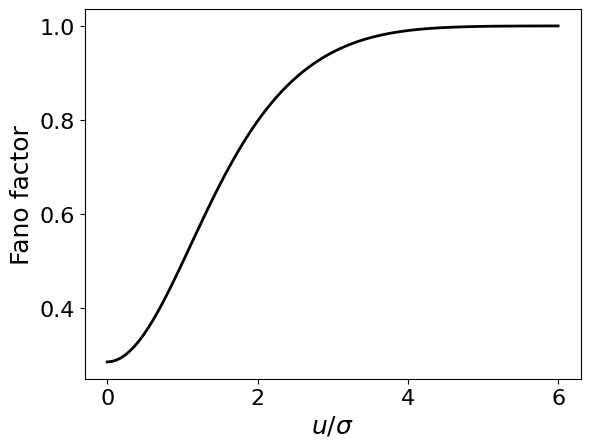

In [24]:
# plotting the fano factor curve as a function of u for any tau
zeta = torch.linspace(0.0, 6.0, 100)
fano_factors = torch.zeros_like(zeta)
for i in range(len(zeta)):
    model = formula.GaussianUpCrossingsDimless(r_func=process.r_squared_exp, u=zeta[i] * sigma, tau=1.0, sigma=sigma)
    fano_factors[i] = model.upcrossing_fano_factor_CLT()

plt.plot(zeta, fano_factors, linewidth=2, color='k')
plt.xlabel(r'$u/\sigma$')
plt.ylabel('Fano factor')

plt.xlabel(r'$u/\sigma$', fontsize=18)
plt.ylabel('Fano factor', fontsize=18)

ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=16)

max_xticks = 5  # Maximum number of tick intervals on x-axis
max_yticks = 5  # Maximum number of tick intervals on y-axis
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=max_xticks, integer=True))
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=max_yticks, integer=True))
plt.show()